6.1

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
Number of HDUs: 2
Image HDU index: 0
First 5 header keywords:
SIMPLE True
BITPIX 16
NAXIS 2
NAXIS1 530
NAXIS2 530
BITPIX: 16
Shape: (530, 530)
dtype: >i2
NAXIS1: 530 NAXIS2: 530
Min: 1507
Max: 15752
Mean: 4795.924268422927
Std: 1848.2526085366376
Median: 4102.0
Mode: 3551


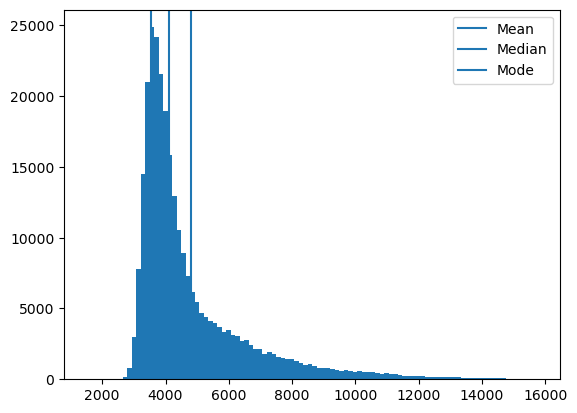

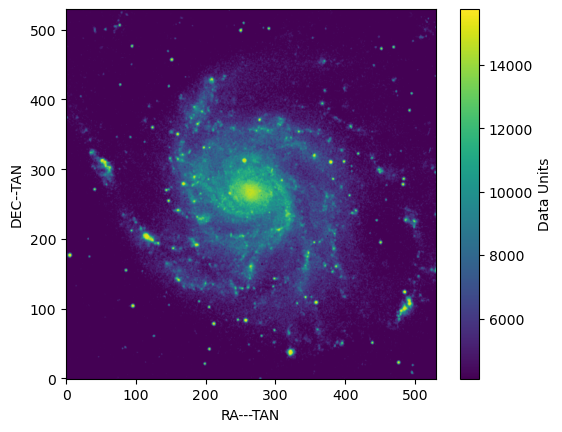

In [11]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

hdul = fits.open('m101.fits')
hdul.info()

print("Number of HDUs:", len(hdul))
print("Image HDU index:", 0)

hdr = hdul[0].header
dat = hdul[0].data

print("First 5 header keywords:")
for i, key in enumerate(hdr.keys()):
    if i < 5:
        print(key, hdr[key])

print("BITPIX:", hdr['BITPIX'])
print("Shape:", dat.shape)
print("dtype:", dat.dtype)
print("NAXIS1:", hdr['NAXIS1'], "NAXIS2:", hdr['NAXIS2'])

flat = dat.flatten()

print("Min:", np.min(flat))
print("Max:", np.max(flat))
print("Mean:", np.mean(flat))
print("Std:", np.std(flat))
print("Median:", np.median(flat))
mode = stats.mode(flat, keepdims=True)[0][0]
print("Mode:", mode)

fig, ax = plt.subplots()
ax.hist(flat, bins=100)
ax.axvline(np.mean(flat), label='Mean')
ax.axvline(np.median(flat), label='Median')
ax.axvline(mode, label='Mode')
ax.legend()
plt.show()

dat_float = np.asarray(dat, dtype=float)
med = np.median(dat_float)

fig, ax = plt.subplots()
im = ax.imshow(dat_float, vmin=med, origin='lower')
ax.set_xlabel(hdr['CTYPE1'])
ax.set_ylabel(hdr['CTYPE2'])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Data Units")
plt.show()

hdr['BUNIT'] = 'Counts'
fits.PrimaryHDU(data=dat_float, header=hdr).writeto('m101_modified.fits', overwrite=True, output_verify='silentfix'
                                        )

6.3

In [2]:
import numpy as np
from astropy.io import fits

dat = fits.getdata('m101.fits').astype(float)

region = dat[100:120, 200:220]  # adjust if needed

rms = np.sqrt(np.mean(region**2))
mean = np.mean(region)
std = np.std(region)

print("RMS:", rms)
print("Mean:", mean)
print("Std:", std)

RMS: 5250.311079593284
Mean: 5106.0125
Std: 1222.4576812077175


6.5

In [7]:
import numpy as np
from astropy.io import fits

d0 = fits.getdata('noisemap0.fits')
d1 = fits.getdata('noisemap1.fits')
d2 = fits.getdata('noisemap2.fits')

print("Std d0:", np.std(d0))
print("Std d1:", np.std(d1))
print("Std d2:", np.std(d2))

stack = np.stack([d0, d1, d2], axis=0)
mean_img = np.mean(stack, axis=0)

print("Std of mean image:", np.std(mean_img))
print("Expected:", np.std(d0) / np.sqrt(3))

Std d0: 9.98401556679484
Std d1: 10.003955116338458
Std d2: 9.995349488722516
Std of mean image: 5.773191380233297
Expected: 5.764274075082415


6.6

In [14]:
from astropy.io import fits
from astropy.table import Table
import numpy as np

hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data

flag = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

DATAFLAG = flag.astype(int)

table = Table(data)
table['DATAFLAG'] = DATAFLAG

parallax = data['GAIAEDR3_PARALLAX'] / 1000
distance = np.where(parallax > 0, 1 / parallax, np.nan)

M = data['GAIAEDR3_PHOT_G_MEAN_MAG'] - 5*np.log10(distance) + 5

M[DATAFLAG == 1] = -1.0

table['ABS_MAG'] = M

table.write('APOGEE_update.fits', overwrite=True)

6.7

    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


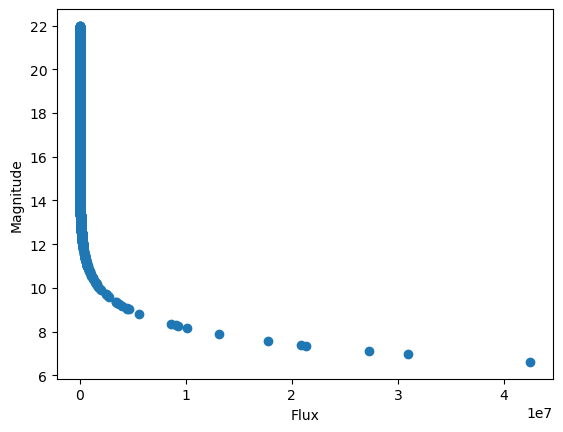

Estimated F0: 18852117942.14138


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('gaiaTestData.csv')

max_flux = df['phot_g_mean_flux'].max()
print(df[df['phot_g_mean_flux'] == max_flux])

df_sorted = df.sort_values('phot_g_mean_flux')

fig, ax = plt.subplots()
ax.scatter(df_sorted['phot_g_mean_flux'], df_sorted['phot_g_mean_mag'])
ax.set_xlabel('Flux')
ax.set_ylabel('Magnitude')
plt.show()

F = df['phot_g_mean_flux']
m = df['phot_g_mean_mag']

F0 = F * 10**(m/2.5)
print("Estimated F0:", np.mean(F0))

6.10

In [10]:
from astroquery.gaia import Gaia

query = """
SELECT TOP 50
source_id, ra, dec, parallax, parallax_error,
phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/parallax_error > 5
AND phot_g_mean_mag IS NOT NULL
AND phot_bp_mean_mag IS NOT NULL
AND phot_rp_mean_mag IS NOT NULL
"""

job = Gaia.launch_job(query)
results = job.get_results()

df = results.to_pandas()

results.write('astroquery_gaia.fits', overwrite=True)

ModuleNotFoundError: No module named 'astroquery'